In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
import joblib

Этап 1: Исследовательский анализ данных (EDA)

In [11]:
df = pd.read_csv('avocado_ripeness_dataset.csv')
df.head()

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
0,14.5,19,40,26,black,34,175,261,ripe
1,71.7,53,69,75,green,69,206,185,pre-conditioned
2,88.5,60,94,46,dark green,79,220,143,hard
3,93.8,105,87,41,dark green,75,299,140,hard
4,42.5,303,58,32,purple,63,200,227,breaking


In [12]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firmness        250 non-null    float64
 1   hue             250 non-null    int64  
 2   saturation      250 non-null    int64  
 3   brightness      250 non-null    int64  
 4   color_category  250 non-null    object 
 5   sound_db        250 non-null    int64  
 6   weight_g        250 non-null    int64  
 7   size_cm3        250 non-null    int64  
 8   ripeness        250 non-null    object 
dtypes: float64(1), int64(6), object(2)
memory usage: 17.7+ KB


(250, 9)

In [13]:
df.describe()

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3
count,250.000000,250.00000,250.000000,250.00000,250.000000,250.000000,250.000000
mean,50.618400,125.94400,64.356000,45.07200,58.016000,220.188000,208.644000
std,27.277678,117.13767,17.377144,19.11629,13.838126,34.405225,55.940564
min,10.300000,1.00000,30.000000,10.00000,30.000000,152.000000,100.000000
25%,25.750000,25.25000,51.250000,31.00000,47.250000,193.250000,155.250000
50%,48.950000,77.00000,65.000000,46.00000,60.000000,220.000000,218.000000
75%,74.050000,278.75000,76.750000,58.00000,68.000000,245.000000,260.500000
max,98.800000,329.00000,99.000000,78.00000,79.000000,299.000000,299.000000


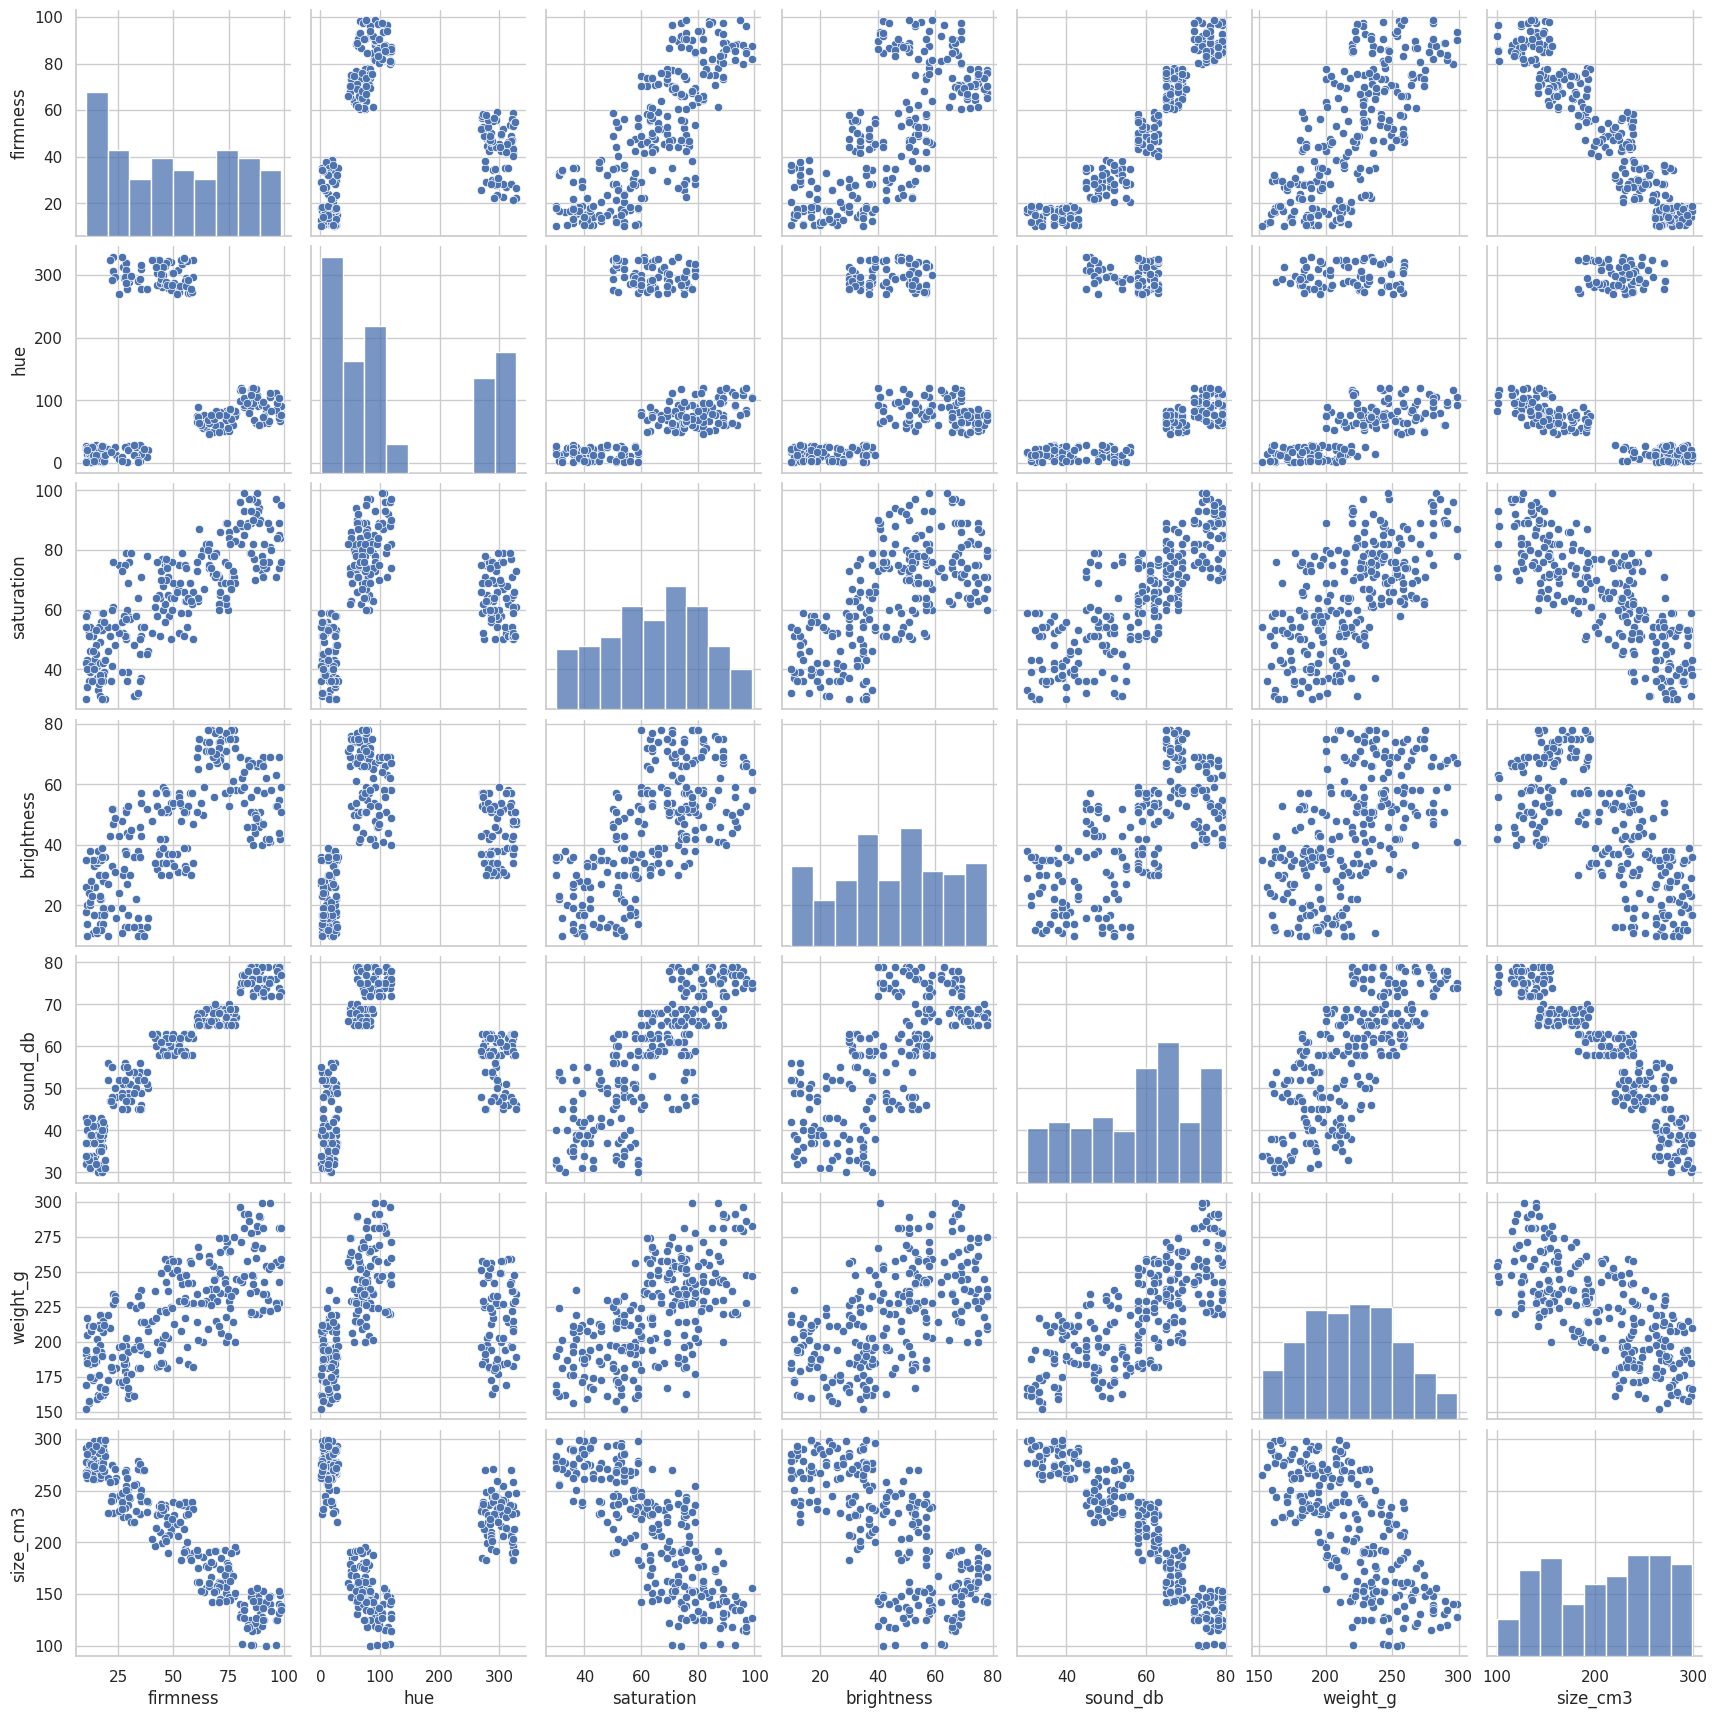

In [26]:
sns.pairplot(data=df)
plt.show()

In [27]:
df.isnull().sum()

,0
firmness,0
hue,0
saturation,0
brightness,0
color_category,0
sound_db,0
weight_g,0
size_cm3,0
ripeness,0


In [28]:
new_df =  pd.get_dummies(df.drop(columns='ripeness'), columns=['color_category'],  drop_first=True).astype(int)

In [29]:
scaler = StandardScaler()
scaler_data = scaler.fit_transform(new_df)

In [30]:
x = scaler_data
y = df['ripeness']

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
model_log = LogisticRegression()
model_tree = DecisionTreeClassifier()

In [36]:
model_log.fit(x_train, y_train)
y_pred_lg = model_log.predict(x_test)

In [37]:
model_tree.fit(x_train, y_train)
y_pred_tree = model_tree.predict(x_test)

In [38]:
print(f'Model log: {accuracy_score(y_test, y_pred_lg)}')
print(f'Model tree: {accuracy_score(y_test, y_pred_tree)}')

Model log: 1.0
Model tree: 1.0


In [39]:
joblib.dump(model_tree, 'model_tree.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [45]:
li = []
for i in new_df:
  subword = 'color_category_'
  if subword in i:
    li.append(i[len(subword):])
print(li)

['dark green', 'green', 'purple']


In [42]:
df.head()

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
0,14.5,19,40,26,black,34,175,261,ripe
1,71.7,53,69,75,green,69,206,185,pre-conditioned
2,88.5,60,94,46,dark green,79,220,143,hard
3,93.8,105,87,41,dark green,75,299,140,hard
4,42.5,303,58,32,purple,63,200,227,breaking
